In [24]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [25]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier

In [26]:
#Load Dataset
df = pd.read_csv("/content/cleaned_job_dataset.csv")

In [27]:
#Feature Selection
y = df['salary_in_usd']
X = df[['experience_level',
        'employment_type',
        'job_category',
        'work_setting',
        'company_size']]

In [28]:
#Convert Categorical Data into Numeric
encoder = LabelEncoder()
for col in X.columns:
    X[col] = encoder.fit_transform(X[col])

df['target'] = df['experience_level'].apply(
    lambda x: 1 if x == 'SE' else 0
)

/tmp/ipykernel_12590/3674605561.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = encoder.fit_transform(X[col])
/tmp/ipykernel_12590/3674605561.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = encoder.fit_transform(X[col])
/tmp/ipykernel_12590/3674605561.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

In [29]:
#Split into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
#Apply Linear Regression Model
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [31]:
y_pred_lr = lr.predict(X_test)
print(y_pred_lr)

[111256.39609903 112870.87074022 110426.91105177 112162.30962969
 114018.79504419 114645.27338721 114501.66355644 114580.83773197
 113049.44899584 114579.83459443 116760.67727026 114098.97235727
 115445.57801862 112726.09487205 111576.00139314 114295.4845397
 115046.79854898 115571.57972228 113469.74832212 112991.79467695
 113328.88418349 111292.65447596 115291.98163478 115611.58692889
 114178.30943265 116236.05899682 114221.0623314  111375.74038102
 111095.30205583 113429.57821565 114657.84273256 112406.48957794
 116354.23724141 113472.49401425 115829.61896796 116476.32721554
 115567.66799275 113814.7852024  111174.47623136 115287.22966756
 114968.62751099 111174.47623136 111798.78539943 114539.66448796
 112323.56657274 114255.31443324 114343.31520538 111777.2655428
 110890.12617664 114216.31036417 112079.38662448 115104.45286787
 114334.48860877 111619.92032928 112568.74965854 114421.32334351
 114698.01283902 110851.12210758 114018.79504419 112358.82181212
 112643.00896699 114544.579

In [32]:
#Evaluating the Linear model
print("R2 Score:",
      r2_score(y_test, y_pred_lr))

R2 Score: -0.006517543134153314


In [33]:
print("MAE:",
      mean_absolute_error(y_test, y_pred_lr))

MAE: 41758.637583292475


In [34]:
rmse = np.sqrt(mean_squared_error(
    y_test,
    y_pred_lr
))

print("RMSE:", rmse)

RMSE: 48542.78910794301


In [35]:
#Apply Decision Tree Model
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print(y_pred_dt)

[106024.42857143 103349.88888889 132905.16666667  87200.
 125177.57142857 127677.          86877.16666667 100910.375
  70972.4        129958.2        117601.5         92691.33333333
 110343.         135063.57142857 111776.75       109825.71428571
 119124.4         99158.85714286 107362.14285714  81219.5
 137114.85714286 101865.875       97110.         103112.85714286
 105863.46666667 149047.5         96276.8         86559.83333333
  97733.75       129291.66666667 156442.4         77298.25
 111706.5         94121.45454545  99846.2        115603.
  99575.75       126748.5        119942.5        115792.75
 110056.         119942.5        138640.3        138024.42857143
 104763.33333333 102515.66666667 125421.25       128987.57142857
  87089.          98896.66666667 109526.75        59873.5
 134194.         104444.25       100335.14285714 100325.
 113087.5        112652.         125177.57142857 106315.
 113443.09090909 112223.375      106562.4         93242.2
 123792.8         82429.666666

In [36]:
#Evaluating Decision Tree Model
print("Decision Tree R2 Score:",
      r2_score(y_test, y_pred_dt))

Decision Tree R2 Score: -0.18285683450093626


In [37]:
#Apply Random Forest Model
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

y_pred_rfc = rfc.predict(X_test)
y_prob_rfc = rfc.predict_proba(X_test)[:,1]

rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)

y_pred_rfr = rfr.predict(X_test)
print(y_pred_rfr)

[103653.79543544 102476.93064139 131970.37974365  85922.85672056
 124842.24778827 129389.50122605  87029.65890548 101744.77571459
  73810.32546861 132442.38227597 118000.44137576  94944.99302453
 111207.62582484 133126.19835398 110379.13323074 112753.95675502
 117480.39916667  99041.71003626 106862.25636217  80300.7505474
 135699.45674531 102354.36827065  97575.05636419 101239.35724759
 104581.0446705  144325.38264935 100148.18514827  88113.86620743
  95946.59927778 131421.47706578 152545.49070757  75672.98953175
 111038.94394156  94311.37053931  99231.83449098 117452.88737013
  99653.55364286 127649.38283911 123743.98038095 112374.52687824
 110598.85016891 123743.98038095 138622.24918094 138067.53702327
 102928.70917213  99746.14456677 126101.66227973 128022.48406474
  87403.59466522  95865.65798624 115585.64453571  71652.3687904
 134765.46476615 101993.28367063 104830.34044145 102469.05308694
 109487.68236822 113194.96201743 124842.24778827 103948.46030952
 114452.96464145 112411.141

In [38]:
##Evaluating Random forest Model
print("Random Forest R2 Score:",
      r2_score(y_test, y_pred_rfr))

Random Forest R2 Score: -0.17445770111105885


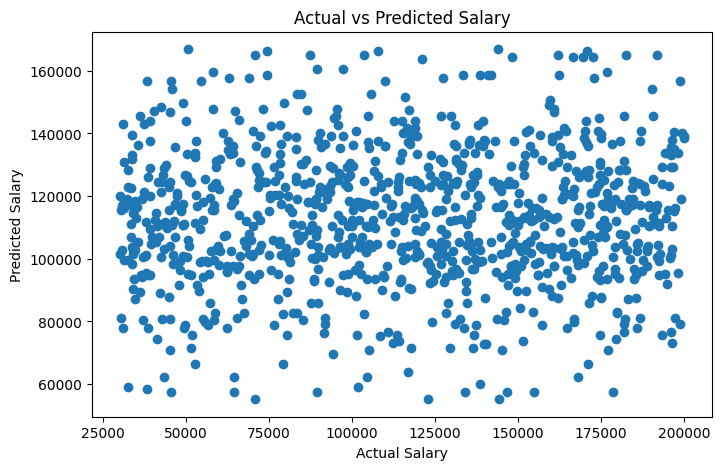

In [39]:
#Visualization of Predictions
plt.figure(figsize=(8,5))

plt.scatter(y_test,
            y_pred_rfr)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.show()

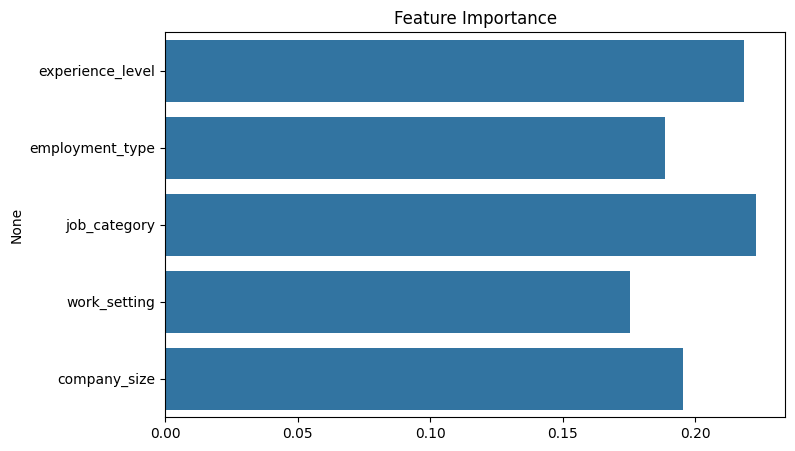

In [40]:
# Feature Importance (Random Forest)
importance = rfr.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

sns.barplot(x=importance,
            y=features)

plt.title("Feature Importance")

plt.show()

In [41]:
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

       30209       0.00      0.00      0.00       1.0
       30290       0.00      0.00      0.00       1.0
       30318       0.00      0.00      0.00       1.0
       30337       0.00      0.00      0.00       1.0
       30339       0.00      0.00      0.00       0.0
       30761       0.00      0.00      0.00       1.0
       30860       0.00      0.00      0.00       1.0
       31076       0.00      0.00      0.00       1.0
       31125       0.00      0.00      0.00       1.0
       31177       0.00      0.00      0.00       1.0
       31207       0.00      0.00      0.00       1.0
       31223       0.00      0.00      0.00       0.0
       31237       0.00      0.00      0.00       1.0
       31316       0.00      0.00      0.00       1.0
       31420       0.00      0.00      0.00       0.0
       31872       0.00      0.00      0.00       0.0
       32192       0.00      0.00      0.00       1.0
       32684       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_